TASK - 3 : Car Price Prediction with Machine Learning

In [2]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached pandas-3.0.5-cp311-cp311-win_amd64.whl (10.0 MB)
                                              0.0/9.3 MB ? eta -:--:--
                                              0.1/9.3 MB 2.6 MB/s eta 0:00:04
     -                                        0.3/9.3 MB 2.8 MB/s eta 0:00:04
     --                                       0.6/9.3 MB 4.3 MB/s eta 0:00:03
     ---                                      0.9/9.3 MB 5.4 MB/s eta 0:00:02
     -----                                    1.2/9.3 MB 5.4 MB/s eta 0:00:02
     ------                                   1.5/9.3 MB 5.7 MB/s eta 0:00:02
     --------                                 2.0/9.3 MB 6.3 MB/s eta 0:00:02
     ----------                               2.4/9.3 MB 6.7 MB/s eta 0:00:02
     ------------                             2.8/9.3 MB 6.9 MB/s eta 0:00:01
     --------------                           3.3/9.3 MB 7.2 MB/s eta 0:00:01
     --


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("All libraries installed successfully!")

All libraries installed successfully!


In [3]:
df = pd.read_csv("car_data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv("car_data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [7]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (301, 9)

Columns:
Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='str')

Data Types:
Car_Name             str
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type            str
Seller_Type          str
Transmission         str
Owner              int64
dtype: object

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [9]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 2


In [11]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (299, 9)


In [12]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [13]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [14]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [15]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

In [16]:
df['Fuel_Type'] = df['Fuel_Type'].str.lower().str.strip()

In [17]:
df['Transmission'] = df['Transmission'].str.lower().str.strip()

In [18]:
df['Seller_Type'] = df['Seller_Type'].str.lower().str.strip()

In [19]:
print(df['Fuel_Type'].unique())
print(df['Transmission'].unique())
print(df['Seller_Type'].unique())

<StringArray>
['petrol', 'diesel', 'cng']
Length: 3, dtype: str
<StringArray>
['manual', 'automatic']
Length: 2, dtype: str
<StringArray>
['dealer', 'individual']
Length: 2, dtype: str


## NOTE
The selected dataset did not contain an address/location field, so no address inconsistency was present.

## Feature Engineering 
Calculating car age from year and extract brand from car name.

In [20]:
df['Car_Age'] = 2026 - df['Year']

In [21]:
df['Car_Name'].head(20)

0              ritz
1               sx4
2              ciaz
3           wagon r
4             swift
5     vitara brezza
6              ciaz
7           s cross
8              ciaz
9              ciaz
10         alto 800
11             ciaz
12             ciaz
13           ertiga
14            dzire
15           ertiga
16           ertiga
18          wagon r
19              sx4
20         alto k10
Name: Car_Name, dtype: str

In [22]:
df['Brand'] = df['Car_Name'].str.split().str[0]

In [23]:
df[['Car_Name', 'Brand']].head(10)

,Car_Name,Brand
0,ritz,ritz
1,sx4,sx4
2,ciaz,ciaz
3,wagon r,wagon
4,swift,swift
5,vitara brezza,vitara
6,ciaz,ciaz
7,s cross,s
8,ciaz,ciaz
9,ciaz,ciaz


In [24]:
df = df.drop(['Car_Name', 'Year'], axis=1)

In [25]:
df.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Brand
0,3.35,5.59,27000,petrol,dealer,manual,0,12,ritz
1,4.75,9.54,43000,diesel,dealer,manual,0,13,sx4
2,7.25,9.85,6900,petrol,dealer,manual,0,9,ciaz
3,2.85,4.15,5200,petrol,dealer,manual,0,15,wagon
4,4.60,6.87,42450,diesel,dealer,manual,0,12,swift


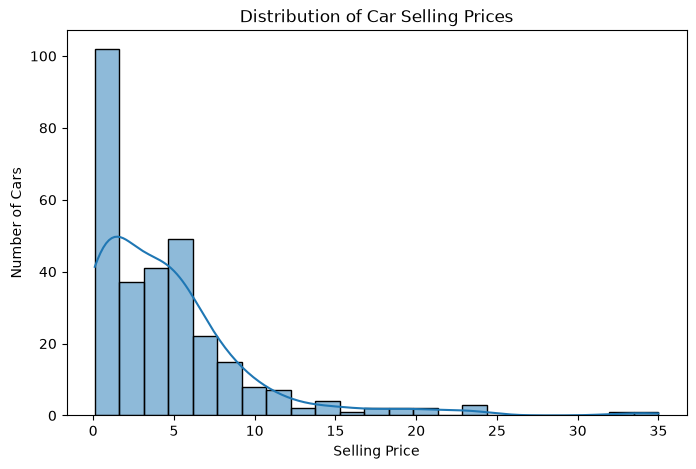

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(df['Selling_Price'], kde=True)

plt.title('Distribution of Car Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Number of Cars')

plt.show()

## Report : 
The distribution plot shows how the selling prices of used cars are distributed. Most vehicles are concentrated in the lower price range, while a smaller number of cars have higher selling prices.

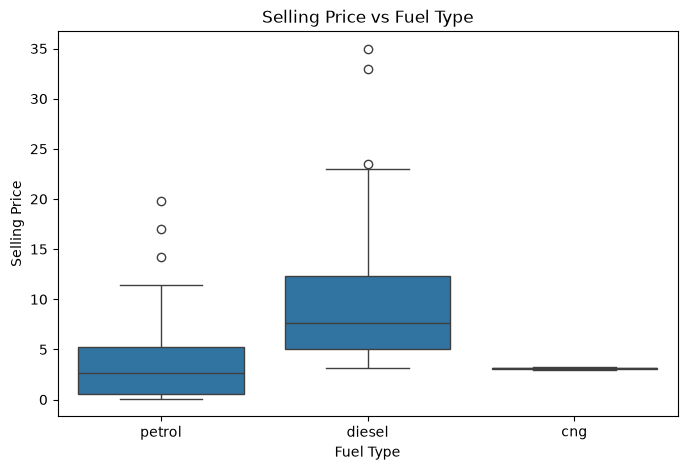

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df)

plt.title('Selling Price vs Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')

plt.show()

## This helps compare selling-price distributions for:
1. Petrol
2. Diesel
3. CNG

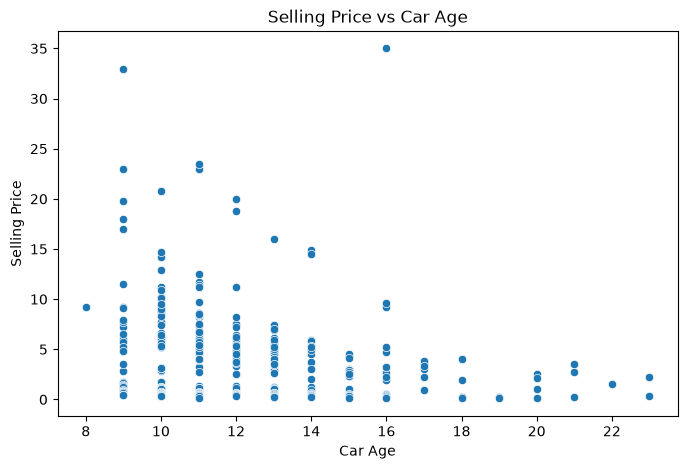

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Car_Age', y='Selling_Price', data=df)

plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age')
plt.ylabel('Selling Price')

plt.show()

# Observation : 
Usually, older cars have lower selling prices.

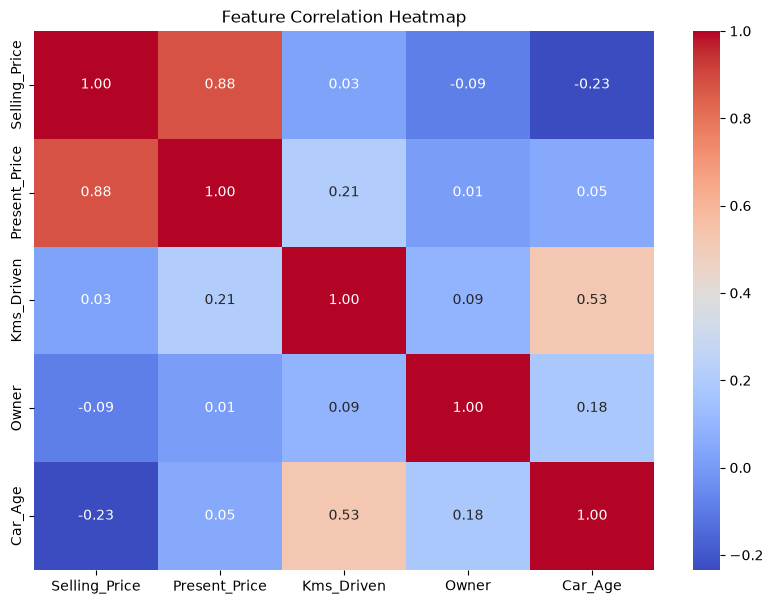

In [29]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Heatmap')

plt.show()

## Correlation tells us how strongly numerical features are related

In [30]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

In [31]:
print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type',
       'Transmission', 'Owner', 'Car_Age', 'Brand'],
      dtype='str')

Target:
Selling_Price


In [32]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
['Fuel_Type', 'Seller_Type', 'Transmission', 'Brand']

Numerical Columns:
['Present_Price', 'Kms_Driven', 'Owner', 'Car_Age']


In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [35]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (239, 8)
Testing data: (60, 8)


In [36]:
linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [37]:
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Present_Price','Kms_Driven','Fuel_Type',...,'Owner','Car_Age','Brand']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated

In [38]:
y_pred_linear = linear_model.predict(X_test)

In [39]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("-----------------------")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R² Score:", r2_linear)

Linear Regression
-----------------------
MAE : 1.3481377656282494
RMSE: 2.388978973867103
R² Score: 0.7785604131766356


In [40]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Present_Price','Kms_Driven','Fuel_Type',...,'Owner','Car_Age','Brand']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated

In [41]:
y_pred_rf = rf_model.predict(X_test)

print(y_pred_rf[:10])

[ 9.5184   7.97605  0.4388   7.333   16.6777   5.307    6.79745  1.18125
  7.8718   0.31355]


In [42]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression")
print("-----------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Regression
-----------------------
MAE : 1.3987775
RMSE: 3.3758607470848596
R² Score: 0.557819429863166


In [43]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_linear, mae_rf],
    'RMSE': [rmse_linear, rmse_rf],
    'R2 Score': [r2_linear, r2_rf]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.348138,2.388979,0.778560
1,Random Forest,1.398778,3.375861,0.557819


## Model Performance Summary

The performance of the two regression models is summarized below:

| Model | MAE | RMSE | R² Score |
|---|---:|---:|---:|
| Linear Regression | 1.3481 | 2.3890 | 0.7786 |
| Random Forest | 1.3988 | 3.3759 | 0.5578 |

Linear Regression performed better than Random Forest based on lower MAE and RMSE and a higher R² score.

In [44]:
linear = linear_model.named_steps['model']

feature_names = linear_model.named_steps['preprocessor'].get_feature_names_out()

coefficients = linear.coef_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute_Importance': np.abs(coefficients)
})

feature_importance = feature_importance.sort_values(
    by='Absolute_Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Importance
36,cat__Brand_innova,2.983641,2.983641
23,cat__Brand_city,1.194128,1.194128
38,cat__Brand_land,-1.060227,1.060227
11,cat__Brand_Honda,-0.910160,0.910160
28,cat__Brand_eon,-0.829739,0.829739
8,cat__Brand_Activa,-0.791784,0.791784
6,cat__Transmission_manual,-0.761360,0.761360
5,cat__Transmission_automatic,0.761360,0.761360
3,cat__Seller_Type_dealer,0.664839,0.664839
4,cat__Seller_Type_individual,-0.664839,0.664839


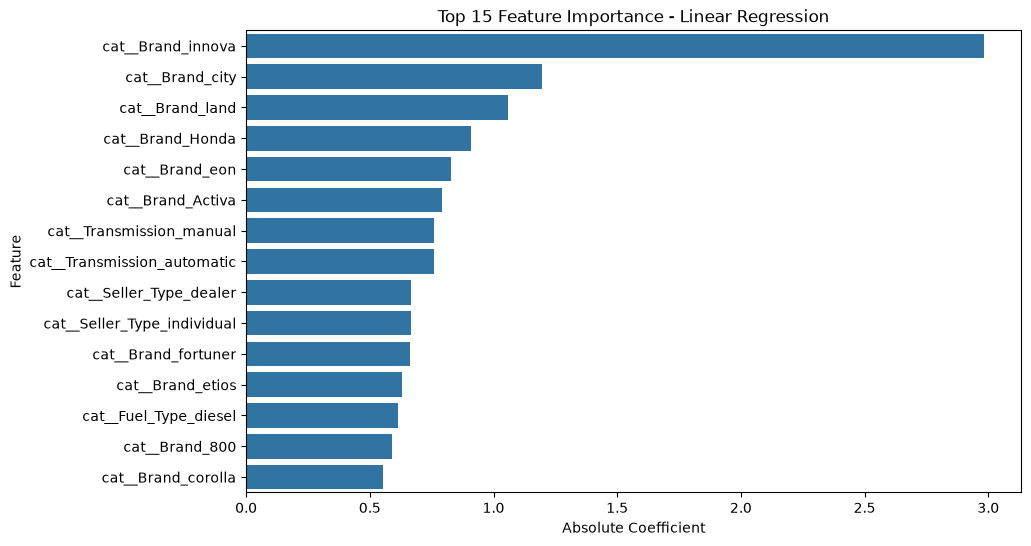

In [45]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Absolute_Importance',
    y='Feature',
    data=feature_importance.head(15)
)

plt.title('Top 15 Feature Importance - Linear Regression')
plt.xlabel('Absolute Coefficient')
plt.ylabel('Feature')

plt.show()

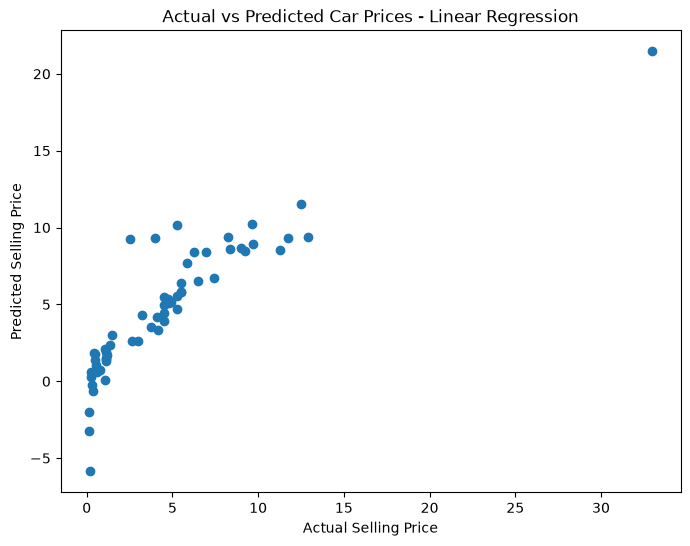

In [46]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_linear)

plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')

plt.title('Actual vs Predicted Car Prices - Linear Regression')

plt.show()

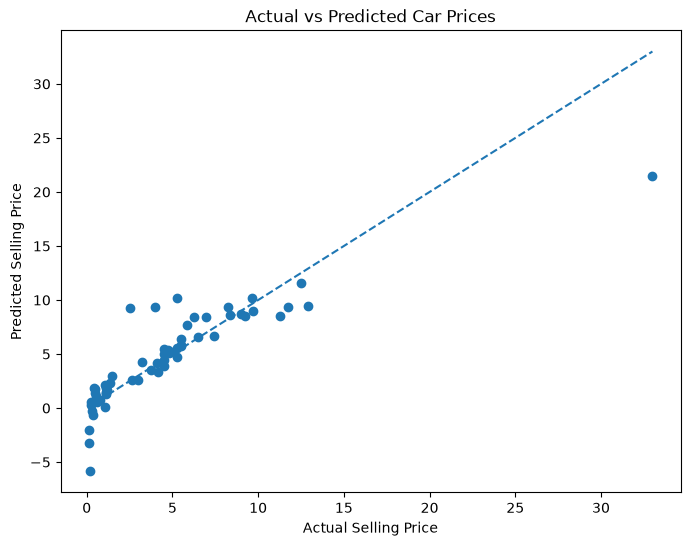

In [47]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_linear)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Car Prices')

plt.show()

In [48]:
new_car = pd.DataFrame({
    'Present_Price': [8.5],
    'Kms_Driven': [30000],
    'Fuel_Type': ['petrol'],
    'Seller_Type': ['dealer'],
    'Transmission': ['manual'],
    'Owner': [0],
    'Car_Age': [5],
    'Brand': ['honda']
})

predicted_price = linear_model.predict(new_car)

print("Predicted Selling Price:", predicted_price[0])

Predicted Selling Price: 7.709281491091443


## Sample Prediction

For the sample car provided to the model, the predicted selling price was approximately **₹7.71 lakhs**.

This demonstrates how the trained model can be used to estimate the selling price of a used car based on its features.

## Conclusion

A machine learning model was developed to predict the selling price of used cars.

The dataset was cleaned by checking missing values, removing duplicate records, and standardizing categorical variables. Feature engineering was performed by calculating car age and extracting a brand/model category from the car name.

Exploratory Data Analysis was performed using selling price distribution, fuel-type box plots, car-age scatter plots, and a correlation heatmap.

Categorical variables were converted into numerical features using One-Hot Encoding. Two regression models, Linear Regression and Random Forest Regression, were trained and evaluated using MAE, RMSE, and R² score.

Based on the test results, Linear Regression performed better than Random Forest.

Linear Regression achieved:
- MAE: 1.3481
- RMSE: 2.3890
- R² Score: 0.7786

Therefore, Linear Regression was selected as the best-performing model for this dataset.